<a href="https://colab.research.google.com/github/HTKhuongNinh-FPTU/Employee-Attrition-Analysis/blob/main/Employee_Attrition_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **FINAL REPORT ADY201m **
# Topic: Employee Atrittion Analysis


**I.DATA IMPORT & OVERVIEW**


In [ ]:
# ==========================================
# CELL 1: SETUP & DATA SELECTION (Preprocessing)
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from google.colab import files
import io

uploaded = files.upload()

# 1. Load dữ liệu
# Nếu bạn chạy trên máy cá nhân, hãy dùng: uploaded = files.upload()
df = pd.read_csv('employee-traits-by-department-and-role.csv')

# 2. Định nghĩa danh sách cột (Chọn lọc 12 cột cốt lõi để báo cáo tinh gọn)
categorical_cols = ['Attrition', 'Department', 'JobRole', 'OverTime']
numerical_cols = ['Age', 'MonthlyIncome', 'DistanceFromHome', 'JobSatisfaction',
                  'EnvironmentSatisfaction', 'JobLevel', 'TotalWorkingYears', 'YearsAtCompany']
# 3. Chuyển đổi định dạng dữ liệu
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

for col in numerical_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("--- Cấu trúc dữ liệu đã thiết lập ---")
df.info()

# ==========================================
# CELL 2: DATA OVERVIEW
# ==========================================
print(f"\nKích thước dataset: {df.shape}")
print("\nThống kê mô tả (Numerical):")
display(df.describe().T)

print("\nKiểm tra giá trị thiếu (Missing values):")
print(df.isnull().sum())
print("\n5 dòng dữ liệu đầu tiên:")
display(df.head())

Saving employee-traits-by-department-and-role.csv to employee-traits-by-department-and-role (7).csv
--- Cấu trúc dữ liệu đã thiết lập ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   EmployeeId                1470 non-null   int64   
 1   Age                       1470 non-null   int64   
 2   Attrition                 1058 non-null   category
 3   BusinessTravel            1470 non-null   object  
 4   DailyRate                 1470 non-null   int64   
 5   Department                1470 non-null   category
 6   DistanceFromHome          1470 non-null   int64   
 7   Education                 1470 non-null   int64   
 8   EducationField            1470 non-null   object  
 9   EmployeeCount             1470 non-null   int64   
 10  EnvironmentSatisfaction   1470 non-null   int64   
 11  Gender                

,count,mean,std,min,25%,50%,75%,max
EmployeeId,1470.0,735.500000,424.496761,1.0,368.25,735.5,1102.75,1470.0
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0



Kiểm tra giá trị thiếu (Missing values):
EmployeeId                    0
Age                           0
Attrition                   412
BusinessTravel                0
DailyRate                     0
Department                    0
DistanceFromHome              0
Education                     0
EducationField                0
EmployeeCount                 0
EnvironmentSatisfaction       0
Gender                        0
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                       0
JobSatisfaction               0
MaritalStatus                 0
MonthlyIncome                 0
MonthlyRate                   0
NumCompaniesWorked            0
Over18                        0
OverTime                      0
PercentSalaryHike             0
PerformanceRating             0
RelationshipSatisfaction      0
StandardHours                 0
StockOptionLevel              0
TotalWorkingYears             0
TrainingTimesLastYear         

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


**II.DATA CLEANING (LÀM SẠCH VÀ TỐI ƯU)**



In [ ]:
# ==========================================
# STEP 2: DATA CLEANING & OPTIMIZATION
# ==========================================
import pandas as pd
import numpy as np


# 1. DANH SÁCH 12 CỘT VÀNG
keep_cols = ['Attrition', 'Age', 'Department', 'JobRole', 'JobLevel',
    'MonthlyIncome', 'OverTime', 'DistanceFromHome', 'JobSatisfaction',
    'EnvironmentSatisfaction', 'TotalWorkingYears', 'YearsAtCompany']

# 2. LỌC CỘT VÀ XỬ LÝ DÒNG TRỐNG
df_clean = df[[c for c in keep_cols if c in df.columns]].copy()
df_clean = df_clean.dropna(subset=['Attrition'])

# 3. CHUẨN HÓA GIÁ TRỊ SANG TIẾNG ANH (Left / Stayed)
# Chuyển đổi: 1.0 -> Left, 0.0 -> Stayed
df_clean['Attrition'] = pd.to_numeric(df_clean['Attrition'], errors='coerce').map({1.0: 'Left', 0.0: 'Stayed'})

# Chuẩn hóa OverTime (Yes/No)
if 'OverTime' in df_clean.columns:
    df_clean['OverTime'] = df_clean['OverTime'].astype(str).str.strip().str.title()

# 4. XỬ LÝ MISSING VALUES
for col in df_clean.columns:
    if df_clean[col].dtype in ['int64', 'float64']:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    else:
        mode_val = df_clean[col].mode()
        if not mode_val.empty:
            df_clean[col] = df_clean[col].fillna(mode_val[0])

# 5. XỬ LÝ OUTLIERS (LƯƠNG)
q3 = df_clean['MonthlyIncome'].quantile(0.75)
iqr = q3 - df_clean['MonthlyIncome'].quantile(0.25)
upper_limit = q3 + 1.5 * iqr
df_clean['MonthlyIncome'] = np.where(df_clean['MonthlyIncome'] > upper_limit, upper_limit, df_clean['MonthlyIncome'])

# 6. HIỂN THỊ VÀ TẢI DỮ LIỆU
print("--- COMPLETE: 12 COLUMNS WITH ENGLISH LABELS ---")
print(f"Total Records: {len(df_clean)}")
display(df_clean.head())

--- COMPLETE: 12 COLUMNS WITH ENGLISH LABELS ---
Total Records: 1058


,Attrition,Age,Department,JobRole,JobLevel,MonthlyIncome,OverTime,DistanceFromHome,JobSatisfaction,EnvironmentSatisfaction,TotalWorkingYears,YearsAtCompany
1,Left,37,Research & Development,Healthcare Representative,2,4777.000,No,11,2,1,15,1
2,Left,51,Research & Development,Research Scientist,1,2461.000,Yes,4,3,1,18,10
3,Stayed,42,Sales,Sales Executive,4,13525.000,No,26,2,3,23,20
6,Stayed,40,Sales,Sales Executive,2,7457.000,Yes,1,4,2,6,4
7,Left,55,Research & Development,Manager,5,17490.875,Yes,2,1,4,24,5


Xuất FILE sạch

In [ ]:

# Xuất file sạch
df_clean.to_csv('hr_cleaned_12_cols.csv', index=False, encoding='utf-8-sig')
#files.download('hr_cleaned_12_cols.csv')

**III.COMPREHENSIVE EDA (PHÂN TÍCH DỮ LIỆU KHÁM PHÁ)**


CELL 1: UNIVARIATE ANALYSIS (PHÂN TÍCH ĐƠN BIẾN)

Mục này phân tích các biến số độc lập để nắm bắt bức tranh tổng quan về đặc điểm nhân sự, cơ cấu thu nhập và tỷ lệ nghỉ việc tại doanh nghiệp


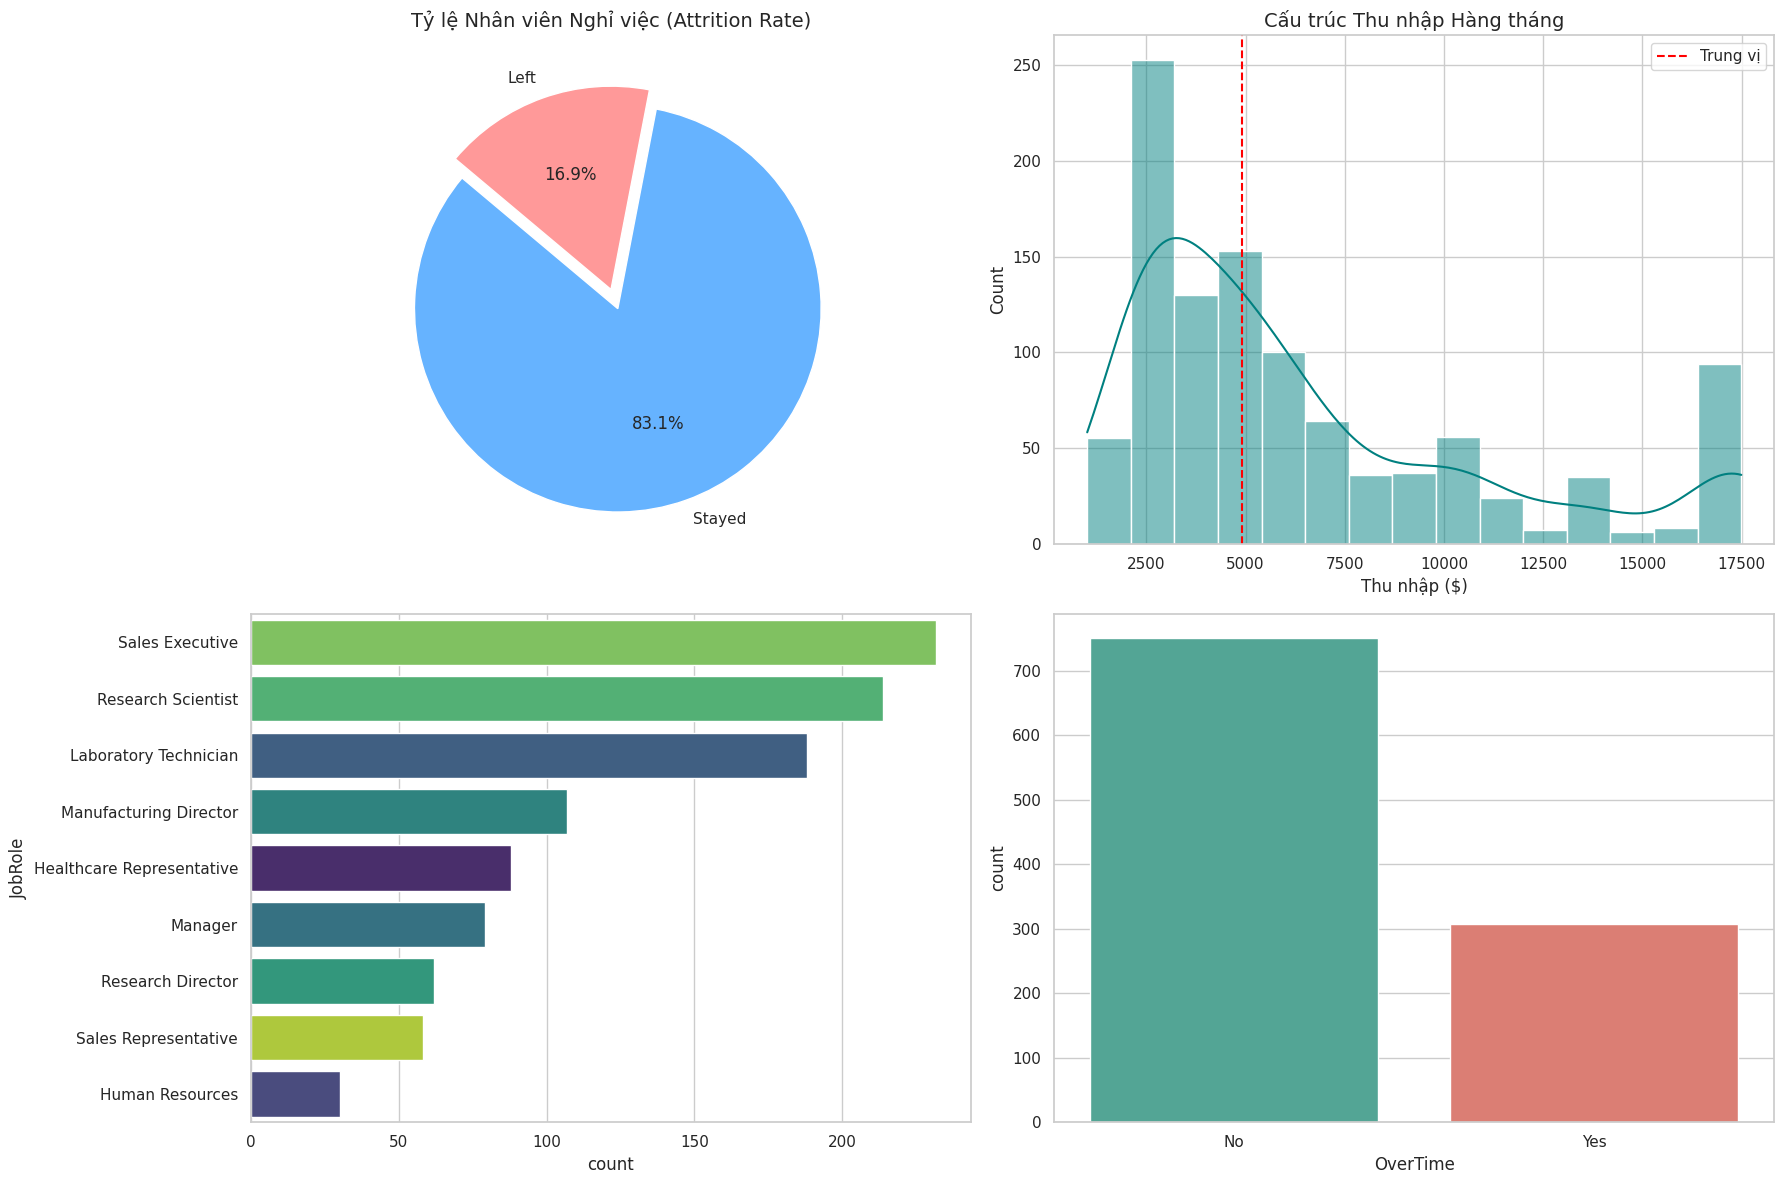

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Thiết lập cấu hình thẩm mỹ cho biểu đồ
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14})
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# --- BIỂU ĐỒ 1: TỶ LỆ NGHỈ VIỆC (ATTRITION) ---
# Mục đích: Cho thấy "sức khỏe" nhân sự tổng quát
attrition_counts = df_clean['Attrition'].value_counts()
axes[0, 0].pie(attrition_counts, labels=attrition_counts.index, autopct='%1.1f%%',
               startangle=140, colors=['#66b3ff', '#ff9999'], explode=(0.1, 0))
axes[0, 0].set_title('Tỷ lệ Nhân viên Nghỉ việc (Attrition Rate)')

# --- BIỂU ĐỒ 2: PHÂN BỔ THU NHẬP (MONTHLY INCOME) ---
# Mục đích: Xác định mặt bằng lương chung (giúp giải thích insight lương thấp dễ nghỉ việc)
sns.histplot(df_clean['MonthlyIncome'], kde=True, color='teal', ax=axes[0, 1])
axes[0, 1].axvline(df_clean['MonthlyIncome'].median(), color='red', linestyle='--', label='Trung vị')
axes[0, 1].set_title('Cấu trúc Thu nhập Hàng tháng')
axes[0, 1].set_xlabel('Thu nhập ($)')
axes[0, 1].legend()

# --- BIỂU ĐỒ 3: CƠ CẤU VỊ TRÍ CÔNG VIỆC (JOB ROLE) ---
# Mục đích: Thấy được nhóm nghề nghiệp nào chiếm đa số trong công ty
sns.countplot(y='JobRole', data=df_clean,
              order=df_clean['JobRole'].value_counts().index,
              hue='JobRole',      # Thêm dòng này để chỉ định biến tô màu
              legend=False,       # Tắt chú thích vì đã có nhãn ở trục y
              palette='viridis', ax=axes[1, 0])

# --- BIỂU ĐỒ 4: TỶ LỆ LÀM THÊM GIỜ (OVERTIME) ---
# Mục đích: Thống kê gánh nặng Overtime hiện tại của toàn công ty
sns.countplot(x='OverTime', data=df_clean,
              hue='OverTime',     # Thêm dòng này
              legend=False,       # Tắt chú thích
              palette=['#45B39D', '#EC7063'], ax=axes[1, 1])
# Tối ưu hóa khoảng cách và hiển thị
plt.tight_layout()
plt.show()

NHẬN XÉT CHUNG

1. Tỷ lệ nghỉ việc (Attrition Rate)
- Tỷ lệ nhân viên nghỉ việc chiếm 16.9%. Đây là con số khá cao, cho thấy doanh nghiệp đang đối mặt với thách thức trong việc giữ chân nhân sự.

2. Thu nhập hàng tháng (Monthly Income)
- Phân phối thu nhập bị lệch phải rõ rệt. Đa số nhân viên có mức lương thấp, tập trung mạnh ở khoảng 2.500$ - 5.000$.

- Đường trung vị (vạch đỏ) nằm ở mức gần 5.000$, cho thấy một nửa đội ngũ đang nhận mức lương dưới ngưỡng này.

3. Phân bổ theo vị trí công việc (Job Role)
- Sales Executive, Research Scientist và Laboratory Technician là 3 nhóm ngành có số lượng nhân sự đông nhất

- Nhóm Human Resources có quy mô nhỏ nhất trong tổ chức.

4. Tình trạng làm thêm giờ (OverTime)
- Phần lớn nhân viên không làm thêm giờ (khoảng hơn 700 người).

- Tuy nhiên, vẫn có một lượng đáng kể (khoảng hơn 300 người) đang làm thêm giờ (Yes). Cần kiểm tra xem nhóm làm thêm giờ này có nằm trong số 16.9% nghỉ việc hay không để có giải pháp điều chỉnh.

CELL 2: BIVARIATE ANALYSIS (PHÂN TÍCH SONG BIẾN )

Mục này thực hiện đối soát trực tiếp giữa biến mục tiêu với 4 đặc tính cốt lõi nhằm bóc tách các mối liên hệ nhân quả, xác định mức độ ảnh hưởng của từng nhân tố và nhận diện các quy luật dẫn đến sự biến động của dữ liệu.

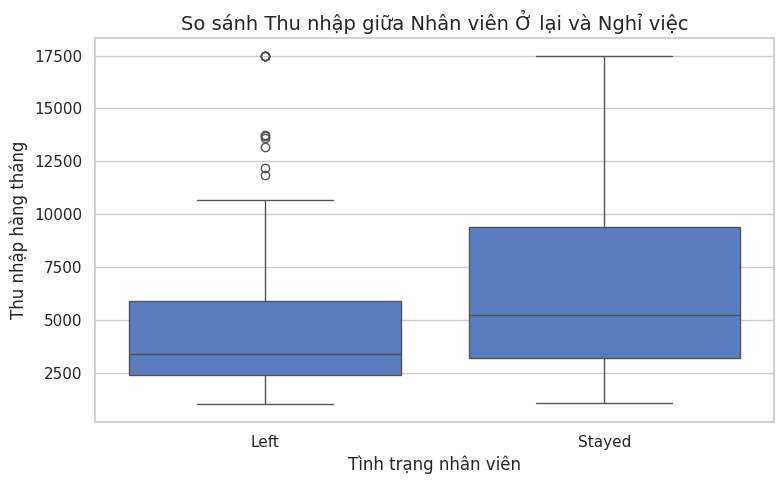

In [ ]:
# ==========================================
# CELL 2.1: ATTRITION VS MONTHLY INCOME
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df_clean
)
plt.title('So sánh Thu nhập giữa Nhân viên Ở lại và Nghỉ việc')
plt.xlabel('Tình trạng nhân viên')
plt.ylabel('Thu nhập hàng tháng')
plt.tight_layout()
plt.show()


• Biểu đồ thứ 1 là biểu đồ Boxplot, dùng để so sánh và đánh giá sự khác biệt về thu nhập hàng tháng (Monthly Income) giữa hai nhóm nhân viên nghỉ việc (Left) và ở lại (Stayed) nhằm phân tích mối liên hệ giữa thu nhập và tình trạng nghỉ việc.

**Nhận xét**: từ biểu đồ có thể thấy, nhóm nhân viên ở lại có mức thu nhập trung bình cao hơn và phân bố rộng hơn so với nhóm nghỉ việc. Trong khi đó, nhóm nghỉ việc chủ yếu tập trung ở mức thu nhập thấp hơn. Điều này cho thấy thu nhập có thể là một yếu tố quan trọng ảnh hưởng đến quyết định nghỉ việc của nhân viên.

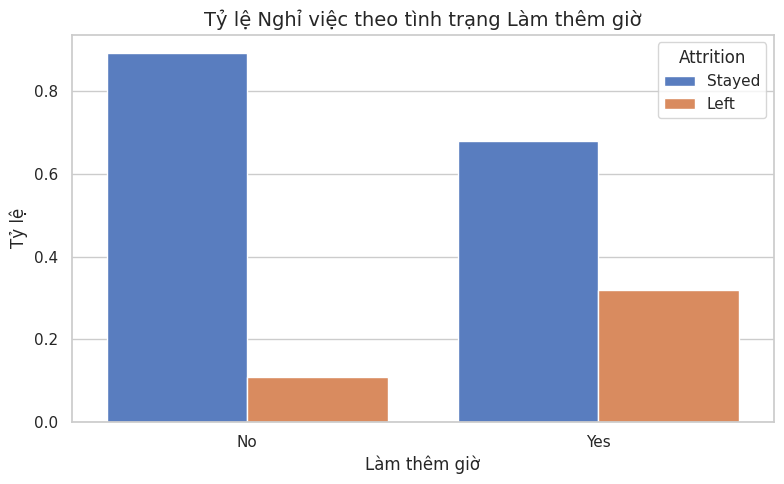

In [ ]:
# ==========================================
# CELL 2.2: ATTRITION RATE BY OVERTIME
# ==========================================
overtime_attrition = (
    df_clean
    .groupby('OverTime')['Attrition']
    .value_counts(normalize=True)
    .rename('Rate')
    .reset_index()
)

plt.figure(figsize=(8, 5))
sns.barplot(
    x='OverTime',
    y='Rate',
    hue='Attrition',
    data=overtime_attrition
)
plt.title('Tỷ lệ Nghỉ việc theo tình trạng Làm thêm giờ')
plt.ylabel('Tỷ lệ')
plt.xlabel('Làm thêm giờ')
plt.tight_layout()
plt.show()


•Biểu đồ thứ 2 là biểu đồ Barplot, dùng để so sánh và đánh giá tỷ lệ nghỉ việc (Attrition) giữa hai nhóm nhân viên có làm thêm giờ (Yes) và không làm thêm giờ (No) nhằm phân tích mối liên hệ giữa việc làm thêm giờ và khả năng nghỉ việc.

**Nhận xét** : từ biểu đồ có thể thấy, nhóm nhân viên làm thêm giờ có tỷ lệ nghỉ việc cao hơn đáng kể so với nhóm không làm thêm, cho thấy làm thêm giờ có thể là một yếu tố ảnh hưởng đến quyết định nghỉ việc của nhân viên.

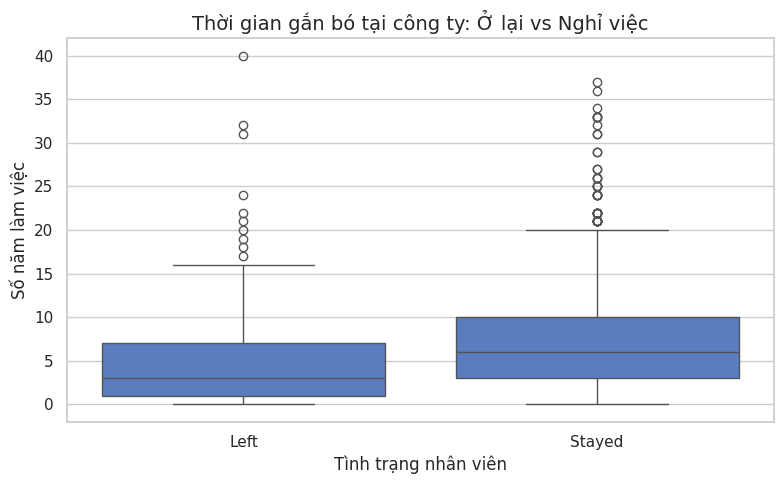

In [ ]:
# ==========================================
# CELL 2.3: ATTRITION VS YEARS AT COMPANY
# ==========================================
plt.figure(figsize=(8, 5))
sns.boxplot(
    x='Attrition',
    y='YearsAtCompany',
    data=df_clean
)
plt.title('Thời gian gắn bó tại công ty: Ở lại vs Nghỉ việc')
plt.xlabel('Tình trạng nhân viên')
plt.ylabel('Số năm làm việc')
plt.tight_layout()
plt.show()


• Biểu đồ thứ 3 là biểu đồ Boxplot, dùng để so sánh và đánh giá sự khác biệt về thời gian gắn bó tại công ty (YearsAtCompany) giữa hai nhóm nhân viên nghỉ việc (Left) và ở lại (Stayed) nhằm phân tích mối liên hệ giữa thâm niên làm việc và tình trạng nghỉ việc

**Nhận xét**: từ biểu đồ có thể thấy, nhóm nhân viên ở lại có số năm làm việc trung bình cao hơn và phân bố rộng hơn so với nhóm nghỉ việc. Trong khi đó, nhóm nghỉ việc chủ yếu tập trung ở những nhân viên có thâm niên thấp. Điều này cho thấy nhân viên làm việc lâu năm có xu hướng gắn bó với công ty hơn, còn những nhân viên mới dễ có khả năng nghỉ việc cao hơn.

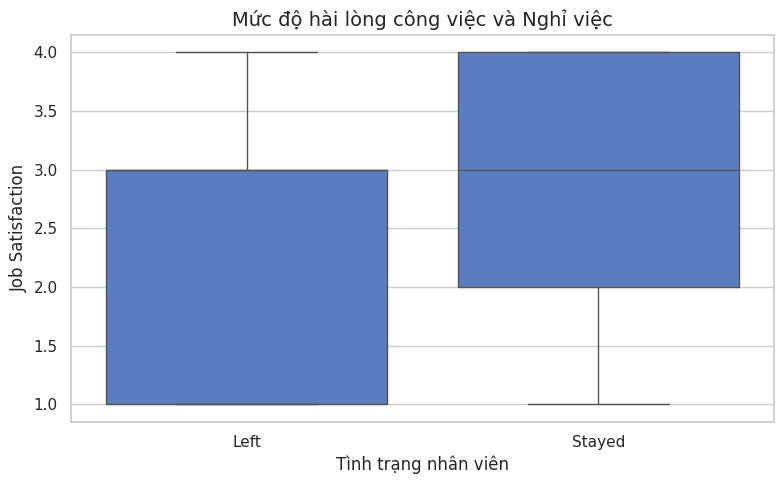

In [ ]:
# ==========================================
# CELL 2.4: ATTRITION VS JOB SATISFACTION
# ==========================================
plt.figure(figsize=(8, 5))
sns.boxplot(
    x='Attrition',
    y='JobSatisfaction',
    data=df_clean
)
plt.title('Mức độ hài lòng công việc và Nghỉ việc')
plt.xlabel('Tình trạng nhân viên')
plt.ylabel('Job Satisfaction')
plt.tight_layout()
plt.show()


•Biểu đồ thứ 4 là biểu đồ Boxplot, dùng để so sánh và đánh giá sự khác biệt về mức độ hài lòng công việc (Job Satisfaction) giữa nhóm nhân viên nghỉ việc (Left) và ở lại (Stayed) nhằm phân tích mối liên hệ giữa sự hài lòng và tình trạng nghỉ việc.

**Nhận xét** : từ biểu đồ có thể thấy, nhóm nhân viên ở lại có mức độ hài lòng công việc trung bình cao hơn và phân bố tập trung hơn, trong khi nhóm nghỉ việc có xu hướng hài lòng thấp hơn và phân tán rộng hơn. Điều này cho thấy mức độ hài lòng công việc có ảnh hưởng rõ rệt đến quyết định nghỉ việc của nhân viên.

**CELL 3: BUSINESS INSIGHTS & RECOMMENDATIONS**

In [ ]:
# ==========================================
# BUSINESS INSIGHTS SUMMARY
# ==========================================

print("\n--- KEY FINDINGS FOR REPORT ---")
print("(All values represent mean or percentage calculated from the dataset)\n")

# ==============================
# 1. Income
# ==============================
avg_income_stay = df_clean[df_clean['Attrition'] == 'Stayed']['MonthlyIncome'].mean()
avg_income_leave = df_clean[df_clean['Attrition'] == 'Left']['MonthlyIncome'].mean()

print(f"1. Chênh lệch thu nhập trung bình (Mean Monthly Income):")
print(f"   - Nghỉ việc: {avg_income_leave:,.0f}")
print(f"   - Ở lại: {avg_income_stay:,.0f}")
print(f"   → Nhóm nghỉ việc có thu nhập thấp hơn đáng kể.\n")

# ==============================
# 2. Overtime
# ==============================
ot_leave_rate = (df_clean[df_clean['OverTime'] == 'Yes']['Attrition'] == 'Left').mean() * 100
no_ot_leave_rate = (df_clean[df_clean['OverTime'] == 'No']['Attrition'] == 'Left').mean() * 100

print(f"2. Ảnh hưởng của Overtime (Attrition Rate):")
print(f"   - Làm thêm: {ot_leave_rate:.1f}%")
print(f"   - Không làm thêm: {no_ot_leave_rate:.1f}%")
print(f"   → Làm thêm giờ làm tăng mạnh khả năng nghỉ việc.\n")

# ==============================
# 3. Job Satisfaction
# ==============================
js_stay = df_clean[df_clean['Attrition'] == 'Stayed']['JobSatisfaction'].mean()
js_leave = df_clean[df_clean['Attrition'] == 'Left']['JobSatisfaction'].mean()

print(f"3. Mức độ hài lòng công việc trung bình (Mean Job Satisfaction):")
print(f"   - Nghỉ việc: {js_leave:.2f}")
print(f"   - Ở lại: {js_stay:.2f}")
print(f"   → Nhân viên nghỉ việc có mức hài lòng thấp hơn.\n")

# ==============================
# 4. Years at Company
# ==============================
years_stay = df_clean[df_clean['Attrition'] == 'Stayed']['YearsAtCompany'].mean()
years_leave = df_clean[df_clean['Attrition'] == 'Left']['YearsAtCompany'].mean()

print(f"4. Thâm niên làm việc trung bình (Mean Years at Company):")
print(f"   - Nghỉ việc: {years_leave:.1f} năm")
print(f"   - Ở lại: {years_stay:.1f} năm")
print(f"   → Nhân viên mới có xu hướng nghỉ nhiều hơn.\n")

# ==============================
# 5. IMPACT RANKING
# ==============================
print("5. Xếp hạng mức độ ảnh hưởng:")
print("   1. Overtime (mạnh nhất)")
print("   2. Job Satisfaction")
print("   3. Monthly Income")
print("   4. Years at Company\n")

# ==============================
# 6. FINAL CONCLUSION
# ==============================
print("--- FINAL INSIGHT ---")
print("Nhân viên có thu nhập thấp, làm thêm nhiều và mức độ hài lòng thấp có xu hướng nghỉ việc cao hơn.")
print("Các yếu tố này là nguyên nhân chính dẫn đến tình trạng biến động nhân sự.\n")

print("(Chi tiết giải pháp được trình bày ở phần Retention Strategy)")


--- KEY FINDINGS FOR REPORT ---
(All values represent mean or percentage calculated from the dataset)

1. Chênh lệch thu nhập trung bình (Mean Monthly Income):
   - Nghỉ việc: 4,818
   - Ở lại: 6,888
   → Nhóm nghỉ việc có thu nhập thấp hơn đáng kể.

2. Ảnh hưởng của Overtime (Attrition Rate):
   - Làm thêm: 31.9%
   - Không làm thêm: 10.8%
   → Làm thêm giờ làm tăng mạnh khả năng nghỉ việc.

3. Mức độ hài lòng công việc trung bình (Mean Job Satisfaction):
   - Nghỉ việc: 2.53
   - Ở lại: 2.80
   → Nhân viên nghỉ việc có mức hài lòng thấp hơn.

4. Thâm niên làm việc trung bình (Mean Years at Company):
   - Nghỉ việc: 5.2 năm
   - Ở lại: 7.4 năm
   → Nhân viên mới có xu hướng nghỉ nhiều hơn.

5. Xếp hạng mức độ ảnh hưởng:
   1. Overtime (mạnh nhất)
   2. Job Satisfaction
   3. Monthly Income
   4. Years at Company

--- FINAL INSIGHT ---
Nhân viên có thu nhập thấp, làm thêm nhiều và mức độ hài lòng thấp có xu hướng nghỉ việc cao hơn.
Các yếu tố này là nguyên nhân chính dẫn đến tình trạn

CELL 4: RETENTION STRATEGIES & MANAGERIAL ACTIONS


--- RETENTION STRATEGY ---

1. Tối ưu chính sách thu nhập (Compensation Strategy)
- Rà soát và điều chỉnh mức lương theo từng cấp độ và nhóm nhân viên.
- Áp dụng cơ chế thưởng hoặc đãi ngộ linh hoạt cho các nhóm có nguy cơ nghỉ việc cao.

2. Quản lý hiệu quả khối lượng làm thêm (Overtime Management)
- Thiết lập giới hạn hợp lý cho thời gian làm thêm.
- Áp dụng luân phiên ca làm và chính sách nghỉ bù để giảm áp lực công việc kéo dài.

3. Xây dựng hệ thống phát hiện rủi ro sớm (Early Warning System)
- Kết hợp nhiều chỉ số để nhận diện nhân viên có nguy cơ nghỉ việc.
- Chủ động triển khai các hoạt động giữ chân như trao đổi định kỳ hoặc hỗ trợ cá nhân hóa.

4. Nâng cao trải nghiệm và môi trường làm việc
- Cải thiện điều kiện làm việc và văn hóa doanh nghiệp.
- Tăng cường vai trò quản lý cấp trung trong việc hỗ trợ và gắn kết nhân viên.

--- CONCLUSION ---

Các giải pháp trên được xây dựng dựa trên các yếu tố có ảnh hưởng lớn đến tình trạng nghỉ việc,
giúp doanh nghiệp đưa ra quyết định dựa trên dữ liệu và giảm thiểu rủi ro mất nhân sự.

--- END ---